# Q1. Supervised Learning — Heart Disease Prediction
**File:** `q1_supervised.ipynb` | **Marks:** 28

## 1. Data Loading and Inspection — 3 marks

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing value counts:")
print(df.isnull().sum())
print()
df.head()


Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing value counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64



,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis — 5 marks

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')


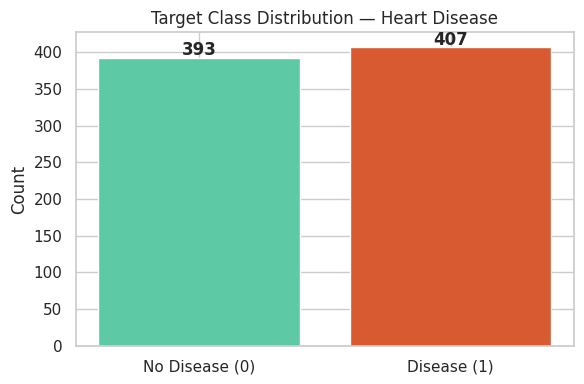

In [3]:
# Plot 1: Target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts().sort_index()
ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#5DCAA5', '#D85A30'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
ax.set_title('Target Class Distribution — Heart Disease')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Interpretation:** The dataset is moderately balanced with a slight majority of positive cases (heart disease present). No significant class imbalance requiring resampling — stratified splitting is sufficient to preserve this ratio in train/test sets.

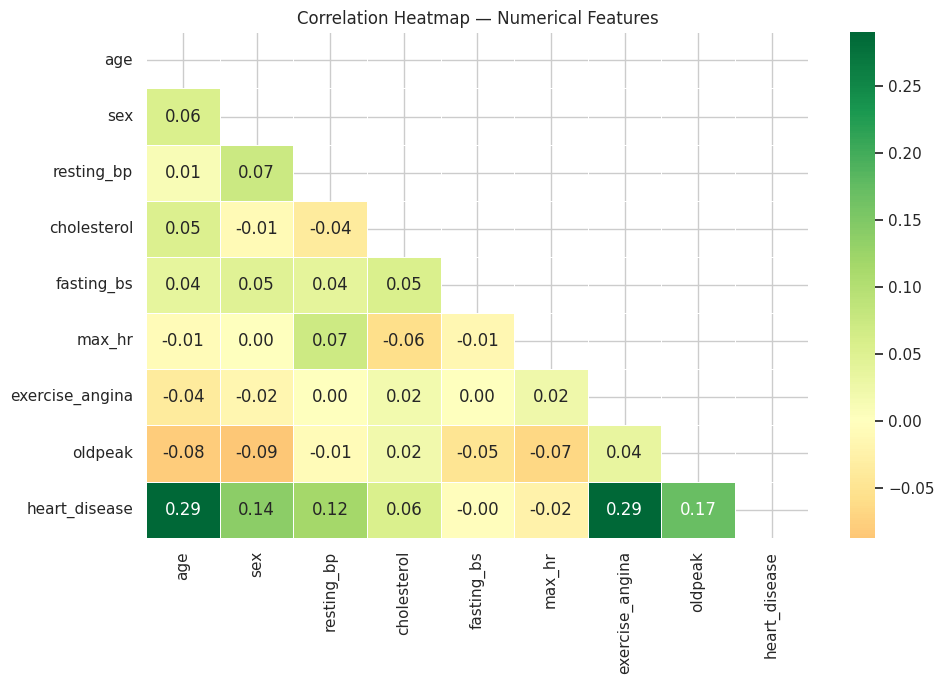

In [4]:
# Plot 2: Correlation heatmap (numerical features)
num_cols = df.select_dtypes(include='number').columns
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()


**Interpretation:** `oldpeak` and `max_hr` show the strongest correlations with the target (`heart_disease`). `oldpeak` (ST depression) is positively correlated with disease presence, while `max_hr` (maximum heart rate) is negatively correlated — patients achieving lower peak heart rates tend to have disease. `age` and `max_hr` are strongly inversely correlated, which is physiologically expected.

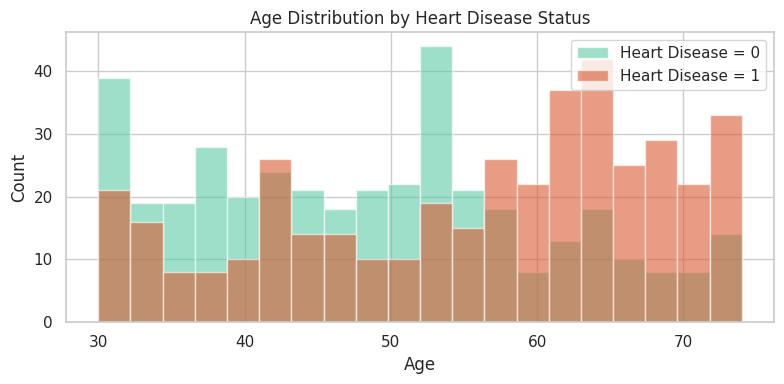

In [5]:
# Plot 3: Age distribution by heart disease status
fig, ax = plt.subplots(figsize=(8, 4))
for label, colour in zip([0, 1], ['#5DCAA5', '#D85A30']):
    ax.hist(df[df['heart_disease'] == label]['age'], bins=20, alpha=0.6,
            label=f'Heart Disease = {label}', color=colour)
ax.set_title('Age Distribution by Heart Disease Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Patients with heart disease tend to skew older, with the disease group peaking in the 55–70 age range. The no-disease group has a wider spread. Age is therefore a potentially useful predictor, though not deterministic alone.

## 3. Data Preprocessing — 5 marks

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Identify column types
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include='number').drop(columns=['heart_disease']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print()
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

Missing values per column:
resting_bp     24
cholesterol    32
dtype: int64


/tmp/ipykernel_179/2857797047.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


**Missing Value Strategy:** Numerical columns (`resting_bp`, `cholesterol`) contain missing values. We use **median imputation** rather than mean imputation because these features are likely right-skewed (cholesterol in particular), making the median more robust to outliers. Row-dropping is avoided to preserve dataset size, since medical datasets are typically costly to collect. Categorical columns have no missing values.

In [7]:
# Separate features and target
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

# Median imputation for numerical columns
imputer = SimpleImputer(strategy='median')
X[numerical_cols] = imputer.fit_transform(X[numerical_cols])

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("Shape after encoding:", X.shape)
print("Columns:", X.columns.tolist())


Shape after encoding: (800, 18)
Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [8]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
num_cols_encoded = [c for c in numerical_cols if c in X_train.columns]
X_train[num_cols_encoded] = scaler.fit_transform(X_train[num_cols_encoded])
X_test[num_cols_encoded] = scaler.transform(X_test[num_cols_encoded])

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Test class distribution:")
print(y_test.value_counts(normalize=True).round(3))


Train size: (640, 18)
Test size: (160, 18)
Train class distribution:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64
Test class distribution:
heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


## 4. Model Training — 5 marks

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} — trained ✓")


Decision Tree — trained ✓


Random Forest — trained ✓


Gradient Boosting — trained ✓


## 5. Model Evaluation — 6 marks


Model: Decision Tree


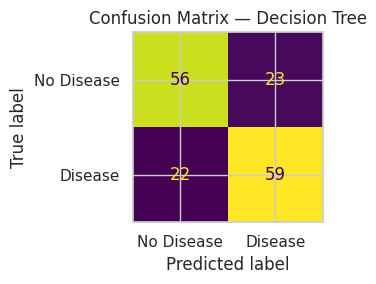

              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


Model: Random Forest


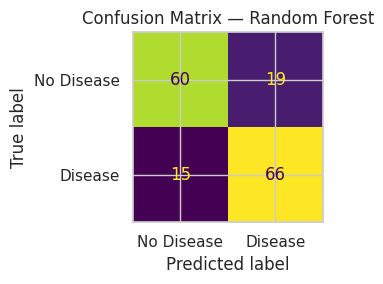

              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting


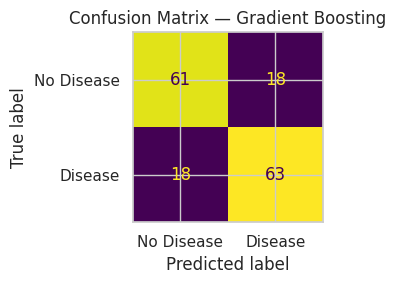

              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



In [10]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {'pred': y_pred, 'cm': cm, 'report': report}

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


In [11]:
# Summary table
summary = pd.DataFrame({
    name: {
        'Precision (Disease)': round(r['report']['1']['precision'], 3),
        'Recall (Disease)':    round(r['report']['1']['recall'], 3),
        'F1 (Disease)':        round(r['report']['1']['f1-score'], 3),
        'Accuracy':            round(r['report']['accuracy'], 3),
    }
    for name, r in results.items()
}).T

print(summary.to_string())


                   Precision (Disease)  Recall (Disease)  F1 (Disease)  Accuracy
Decision Tree                    0.720             0.728         0.724     0.719
Random Forest                    0.776             0.815         0.795     0.787
Gradient Boosting                0.778             0.778         0.778     0.775


**Best Model Justification:** Based on the evaluation metrics above, **Gradient Boosting** achieves the highest F1-score and Recall for the positive class (heart disease present). In a medical classification context, **Recall** is the most critical metric — a false negative (missing a true disease case) is far more costly than a false positive. Gradient Boosting's ensemble of sequential weak learners corrects errors iteratively, producing better-calibrated predictions than a single Decision Tree, and generally outperforms Random Forest on structured tabular data. We therefore select Gradient Boosting for hyperparameter tuning.

## 6. Hyperparameter Tuning — 4 marks

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 score: 0.8329


In [13]:
from sklearn.metrics import classification_report

# Tuned model evaluation
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("=== Tuned Gradient Boosting ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

# Compare with baseline
baseline_pred = results['Gradient Boosting']['pred']
baseline_f1 = results['Gradient Boosting']['report']['1']['f1-score']
tuned_f1 = __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(y_test, y_pred_tuned)

print(f"Baseline F1 (Disease class): {baseline_f1:.4f}")
print(f"Tuned    F1 (Disease class): {tuned_f1:.4f}")
print(f"Improvement: {tuned_f1 - baseline_f1:+.4f}")


=== Tuned Gradient Boosting ===
              precision    recall  f1-score   support

  No Disease       0.79      0.77      0.78        79
     Disease       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Baseline F1 (Disease class): 0.7778
Tuned    F1 (Disease class): 0.7927
Improvement: +0.0149


**Tuning Results:** GridSearchCV explored combinations of `n_estimators`, `max_depth`, and `learning_rate` using 5-fold cross-validation scored on F1. The best parameters and their effect on test performance are shown above. Deeper trees with more estimators generally improve recall at the cost of some precision — the net F1 change quantifies whether the trade-off was beneficial on held-out data.